# Exp. 4: Modern SMB Field and Debris
Here we take our steady state glacier and provide a step change to modern day observations of climate while including debris

SMB curves are taken from 2011 MORA water year report (NPS Pub)

In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, max_value, conditional, pi
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
from irksome import Dt
import cmcrameri.cm as cmc
from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)
from firedrake.mg.mesh import MeshHierarchy
from tqdm.notebook import trange, tqdm
from icepack2.constants import gravity as g, ice_density as ρ_I, glen_flow_law, water_density as ρ_W
from icepack2.constants import gravity, ice_density, glen_flow_law
from icepack2 import model
from icepack2.model.variational import momentum_balance, flow_law, friction_law

cmap2 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'yellow', 'tab:orange', 'tab:red'])

In [2]:
with firedrake.CheckpointFile('emmons-SteadySMBElev.h5', "r") as chk:
    mesh = chk.load_mesh()
    timesteps = np.array(chk.h5pyfile["timestep"])
    b = chk.load_function(mesh, name="bed", idx=len(timesteps) - 1)
    w = chk.load_function(mesh, name="mono", idx=len(timesteps) - 1)

In [3]:
A = icepack.rate_factor(Constant(279.15))
n = Constant(glen_flow_law)

In [4]:
# Reconstruct Function Spaces and Project Functions
dg0 = firedrake.FiniteElement("DG", "triangle", 0)
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
cg1 = firedrake.FiniteElement("CG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1)
V = firedrake.VectorFunctionSpace(mesh, cg1)
Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)

In [5]:
A = icepack.rate_factor(Constant(279.15))
n = Constant(glen_flow_law)

u, M, τ, h = firedrake.split(w)
s_0 = h + b
s = firedrake.project(s_0, Q)

W = V * Σ * T * Q

In [6]:
u = firedrake.Function(V)

Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)
Z = V * Σ * T
z = firedrake.Function(Z)

In [7]:
τ_c = Constant(0.1) # Critical Stress (set to 0.1 mPa)
ε_c = Constant(A * τ_c ** n) # multiply by very small Λ for SIA-like

K = h * A / (n + 2)

t = Constant(0.0)
U_0 = Constant(20.0)
ΔU = Constant(15.0)

U_c = U_0 + ΔU * firedrake.sin(2 * pi * t)# + ϕ) # Critical velocity -> 0 completely turns of long. stress (SIA-like) 100
#U_c = Constant(8.0) 
u_c = K * τ_c ** n + U_c

In [8]:
glen_rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

α = firedrake.Constant(1e-4)
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
}

u, M, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
}

v, N, σ = firedrake.TestFunctions(Z)

In [9]:
degree = 1
qdegree = max(8, degree ** glen_flow_law)
inflow_ids = [1]
#side_wall_ids = [1, 3]
bc = firedrake.DirichletBC(Z.sub(0), Constant((5.0, 11.0)), inflow_ids)# -----> Inflow set to some velocity prof 5.0, 11.0
pparams = {
    "bcs": bc,
    "form_compiler_parameters": {"quadrature_degree": qdegree},
}

sparams = {
    "solver_parameters": {
        "snes_monitor": None,
        #"snes_linesearch_monitor": None,
        "snes_type": "newtonls",
        "snes_max_it": 200,
        "snes_divergence_tolerance": 1e250,
        "snes_linesearch_type": "l2",
        "snes_linesearch_max_it": 5,
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

In [10]:
H = Constant(100.0)

F = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

momentum_problem = firedrake.NonlinearVariationalProblem(F, z, **pparams)
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, **sparams)

In [11]:
num_continuation_steps = 10
for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
    n.assign(exponent)
    momentum_solver.solve()

  0 SNES Function norm 4.359569116450e+05
  1 SNES Function norm 3.188722663831e-07
  0 SNES Function norm 6.025257481454e+08
  1 SNES Function norm 5.392905274242e+06
  2 SNES Function norm 6.191024113153e+04
  3 SNES Function norm 2.915093867560e+01
  4 SNES Function norm 1.201848199996e-04
  0 SNES Function norm 3.695892020480e+08
  1 SNES Function norm 3.574091096388e+06
  2 SNES Function norm 7.470714952389e+04
  3 SNES Function norm 1.393883297871e+02
  4 SNES Function norm 3.415383390958e-03
  0 SNES Function norm 2.263888834940e+08
  1 SNES Function norm 2.097964795146e+06
  2 SNES Function norm 4.353513366139e+04
  3 SNES Function norm 1.031468582847e+02
  4 SNES Function norm 2.417996174564e-03
  0 SNES Function norm 1.387542453963e+08
  1 SNES Function norm 1.226712083463e+06
  2 SNES Function norm 1.906568245381e+04
  3 SNES Function norm 2.997433786133e+01
  4 SNES Function norm 2.088684233520e-04
  0 SNES Function norm 8.497230869692e+07
  1 SNES Function norm 6.941843532

In [12]:
u_init, M_init, τ_init = z.subfunctions
u_init.dat.data_ro.max()

np.float64(151.26824147978783)

In [13]:
s_min = s.dat.data_ro.min()
s_max = s.dat.data_ro.max()
s_diff = int(np.round(s_max - s_min))

s_vals = np.linspace(s_min, s_max, s_diff)
a_vals = np.zeros(s_diff)

a_max = 3
ela = 3700

z = [s_min, ela, s_max] #[s0, ela OR wind_elev, smax]
b_dot = [-5, 3, 1.5] # [b_t, b_max, a_max OR wind scour]

# Slope calculations
m1 = (b_dot[1] - b_dot[0]) / (z[1] - z[0])         # Normal da/dz
y1_int = b_dot[1] - m1 * z[1]

m2 = (b_dot[2] - b_dot[1]) / (z[2] - z[1])         # Wind scour da/dz
y2_int = b_dot[2] - m2 * z[2]

debris_melt = -1.5
debris_elev = 2000

In [14]:
# Actual expression for the SMB
expr3 = conditional(                               # Below wind scour
    ela >= s,
    (m1 * s) + y1_int,
    0,
)

expr2 = conditional(                                # Above wind scour
    ela < s,                                        #condition
    min_value(a_max, y2_int + (m2 * s)),
    expr3,                                          # false val
)

expr = conditional( # At and below debris cover  
    debris_elev > s,
    debris_melt, 
    expr2
)

def smb2(s):
    return expr

a = firedrake.Function(Q).interpolate(smb2(s))
a.dat.data_ro.sum()

np.float64(-3334.9770335687977)

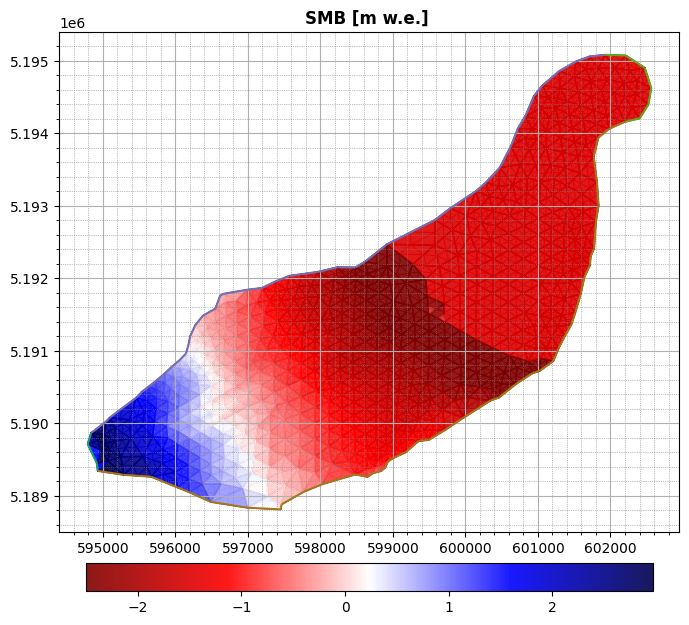

In [15]:
fig, axes = plt.subplots(figsize = (8, 8), sharex = True, sharey = True)

axes.set_aspect("equal")
firedrake.triplot(mesh,
                  axes=axes)
colors = firedrake.tripcolor(a, 
                             vmin = -2.5,
                             #vmax = 4,
                             alpha = 0.9, 
                             cmap = 'seismic_r',
                             axes=axes)

fig.colorbar(colors, fraction=0.046, pad=0.05, orientation = 'horizontal')
axes.set_title('SMB [m w.e.] ', fontweight = 'bold')

axes.xaxis.set_minor_locator(AutoMinorLocator())
axes.tick_params(which='both')
axes.tick_params(which='major')
axes.tick_params(which='minor')
axes.yaxis.set_minor_locator(AutoMinorLocator())

axes.grid()
axes.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

In [16]:
u, M, τ, h = firedrake.split(w)
v, N, σ, η = firedrake.TestFunctions(W)

Γ = 1e-4

fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": b + h,
}

F_momentum = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

F_mass = model.mass_balance(thickness=h, velocity=u, accumulation=a, test_function=η)

F = F_momentum + F_mass

In [17]:
tableau = irksome.BackwardEuler()
dt = Constant(1.0/365.25)

lower = firedrake.Function(W)
upper = firedrake.Function(W)
lower.assign(-np.inf)
upper.assign(+np.inf)
lower.subfunctions[3].assign(0.0)
bounds = ("stage", lower, upper)

vparams = {
    "snes_monitor": ":emmons-output-vi.log",
    "snes_type": "vinewtonrsls",
    "snes_max_it": 200,
    "snes_divergence_tolerance": 1e250,
    "snes_linesearch_type": "l2",
    "snes_linesearch_max_it": 20,
    "ksp_type": "gmres",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

bc = firedrake.DirichletBC(W.sub(0), Constant((0, 0)), inflow_ids)# + side_wall_ids)

fc_params = {"quadrature_degree": 6}
bparams = {
    "solver_parameters": vparams,
    "form_compiler_parameters": fc_params,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": bounds,
}

solver = irksome.TimeStepper(F, tableau, t, dt, w, **bparams)

In [18]:
#New Run w/ debris cover
us = [w.subfunctions[0].copy(deepcopy=True)]
hs = [w.subfunctions[3].copy(deepcopy=True)]
a_s = []
Uc_list = []

dt.assign(1.0/12)
final_time = 200.0
num_steps = int(final_time / float(dt))
timesteps = np.linspace(0, final_time, num_steps + 1)
for step in trange(num_steps):
        
    s.interpolate(b + h) 
    
    solver.advance()
    h = w.subfunctions[3]
    a.interpolate(smb2(b + h))
    t.assign(t + dt)
        
    us.append(w.subfunctions[0].copy(deepcopy=True))
    hs.append(w.subfunctions[3].copy(deepcopy=True))
    a_s.append(a.copy(deepcopy=True))
    Uc_list.append(float(U_c))

  0%|          | 0/2400 [00:00<?, ?it/s]

In [19]:
# Calculate volume and mass added through time
volumes = np.array([firedrake.assemble(h*dx) / 1e9 for h in hs])
mass_b = np.array([firedrake.assemble(a*dx) for a in a_s])

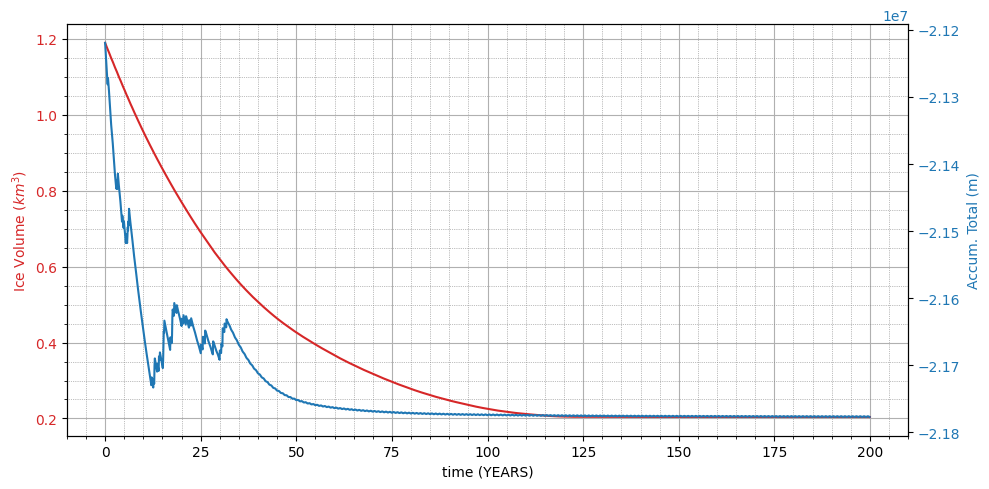

In [20]:
# Steady State Plot
x_steps = np.arange(0, num_steps + 1, 1)
x_steps = x_steps / 12

fig, ax1 = plt.subplots(figsize = (10, 5))
color = 'tab:red'
ax1.set_xlabel('time (YEARS)')
ax1.set_ylabel("Ice Volume ($km^3$)", color=color)
ax1.plot(x_steps, volumes, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Accum. Total (m)', color=color)
ax2.plot(x_steps[0:-1], mass_b, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(which='both')
ax1.tick_params(which='major')
ax1.tick_params(which='minor')
ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax1.grid()
ax1.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()
plt.show()

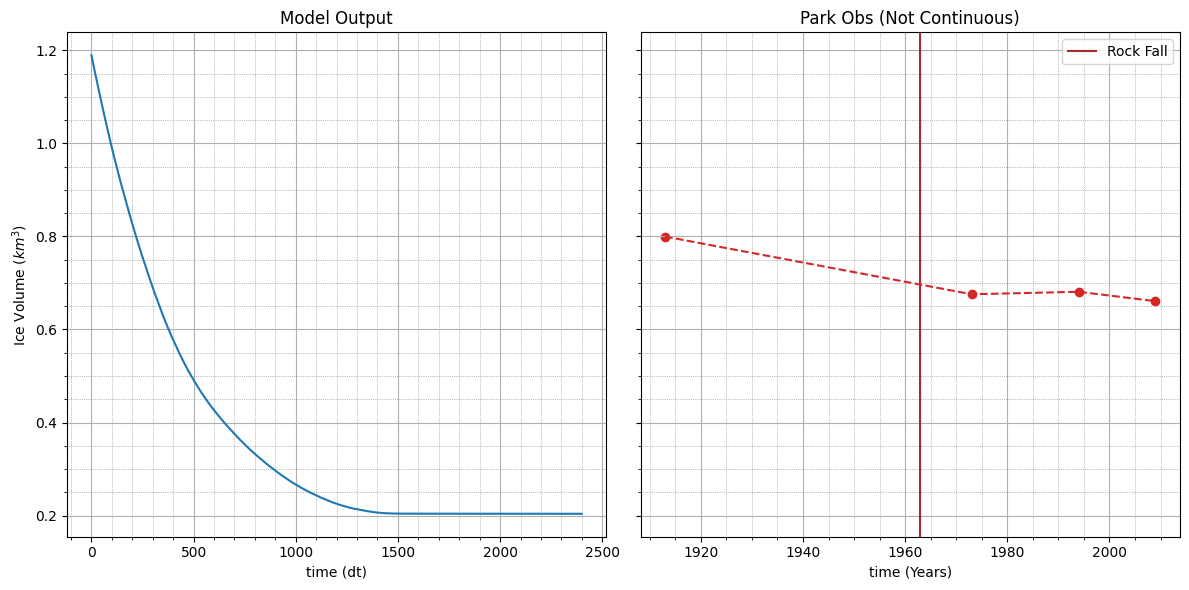

In [21]:
# Park Data Comparison 
park_date = [1896, 1913, 1973, 1994, 2009, 2015] # year
park_vol = [1.2461, 0.7997, 0.6757, 0.681, 0.6608, 0.6648] # km^3

fig, ax = plt.subplots(1, 2, figsize = (12, 6), sharey = True)
color = 'tab:blue'
ax[0].set_title('Model Output')
ax[0].set_xlabel('time (dt)')
#ax[0].set_ylim(0.65, 0.85)
ax[0].set_ylabel("Ice Volume ($km^3$)")
ax[0].plot(volumes, color=color)
ax[0].tick_params(axis='y')

ax[0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0].tick_params(which='both')
ax[0].tick_params(which='major')
ax[0].tick_params(which='minor')
ax[0].yaxis.set_minor_locator(AutoMinorLocator())

ax[0].grid()
ax[0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

color = 'tab:red'
ax[1].set_title('Park Obs (Not Continuous)')
ax[1].set_xlabel('time (Years)')
#ax[1].set_ylim(0.65, 0.85)
ax[1].axvline(x = 1963, color = 'brown', label = 'Rock Fall')
#ax[1].set_ylabel("Ice Volume ($km^3$)", color=color)
ax[1].plot(park_date[1:-1], park_vol[1:-1], color=color, linestyle ='--')
ax[1].scatter(park_date[1:-1], park_vol[1:-1], color=color)
ax[1].tick_params(axis='y', labelcolor=color)
ax[1].legend()

ax[1].xaxis.set_minor_locator(AutoMinorLocator())
ax[1].tick_params(which='both')
ax[1].tick_params(which='major')
ax[1].tick_params(which='minor')
ax[1].yaxis.set_minor_locator(AutoMinorLocator())

ax[1].grid()
ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()

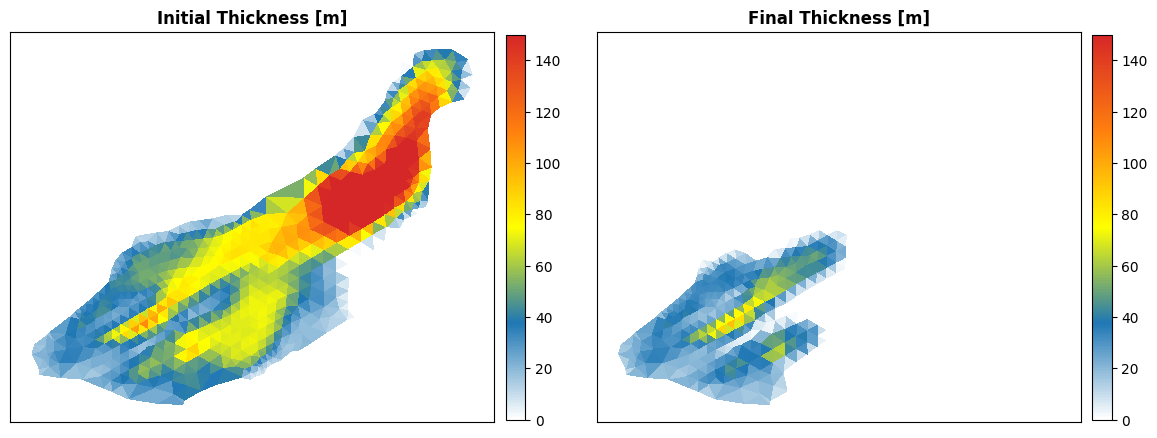

In [22]:
# Final Thickness check to see where 0 thickness exists
fig, axes = plt.subplots(1, 2, figsize = (12,8))

axes[0].set_title('Initial Thickness [m]', fontweight = 'bold')
axes[0].set_aspect("equal")
colors1 = firedrake.tripcolor(hs[0], 
                             num_sample_points=1, 
                             cmap = cmap2,
                             vmin = 0,
                             vmax = 150,
                             shading="flat", 
                             axes=axes[0])
fig.colorbar(colors1, orientation = 'vertical', shrink=0.5, pad = 0.02)
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].set_title('Final Thickness [m]', fontweight = 'bold')
axes[1].set_aspect("equal")
colors1 = firedrake.tripcolor(hs[-1], 
                             num_sample_points=1, 
                             cmap = cmap2,
                             vmin = 0,
                             vmax = 150,
                             shading="flat", 
                             axes=axes[1])
fig.colorbar(colors1, orientation = 'vertical', shrink=0.5, pad = 0.02)
axes[1].set_aspect("equal")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()

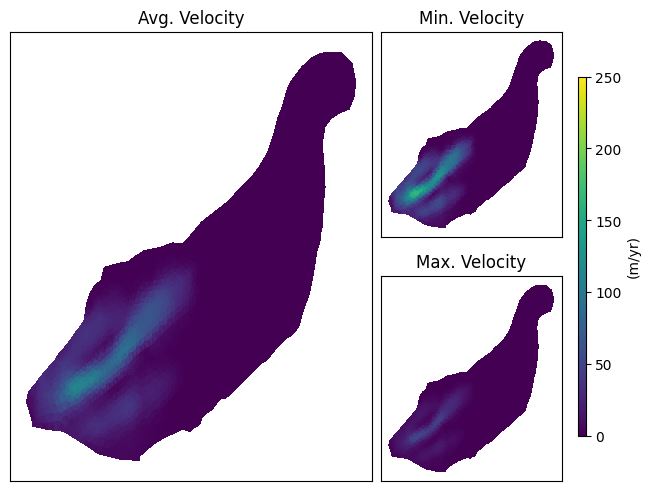

In [23]:
fig = plt.figure(constrained_layout=True)
axs = fig.subplot_mosaic([['Left', 'TopRight'],['Left', 'BottomRight']],
                          gridspec_kw={'width_ratios':[2, 1]})

axs['Left'].set_title('Avg. Velocity')
colors = firedrake.tripcolor(us[-7],
                              vmax = 250, 
                              shading="flat", 
                              axes=axs['Left'])
axs['Left'].set_xticks([])
axs['Left'].set_yticks([])
axs['Left'].grid()
axs['Left'].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

axs['TopRight'].set_title('Min. Velocity')
colors = firedrake.tripcolor(us[-10],
                              vmax = 250, 
                              shading="flat", 
                              axes=axs['TopRight'])
axs['TopRight'].set_xticks([])
axs['TopRight'].set_yticks([])

axs['BottomRight'].set_title('Max. Velocity')
colors = firedrake.tripcolor(us[-4],
                              vmax = 250, 
                              shading="flat", 
                              axes=axs['BottomRight'])
axs['BottomRight'].set_xticks([])
axs['BottomRight'].set_yticks([])

fig.colorbar(colors, ax=[axs['Left'], axs['TopRight'], axs['BottomRight']],
             orientation = 'vertical', 
             shrink=0.8, 
             pad = 0.03, 
             aspect=50,
             label = '(m/yr)')

In [24]:
%%capture

fig, axes = plt.subplots(figsize = (8,8))
axes.set_aspect("equal")

colors = firedrake.tripcolor(hs[0], 
                             vmax= 200, 
                             cmap = 'rainbow',
                             shading="gouraud",
                             num_sample_points=4, 
                             axes=axes)
fig.colorbar(colors, 
             shrink=0.5, 
             pad = 0.02);

In [25]:
from matplotlib.animation import FuncAnimation

fn_plotter = firedrake.FunctionPlotter(mesh, num_sample_points=4)
def animate(h):
    colors.set_array(fn_plotter(h))

animation = FuncAnimation(fig, animate, tqdm(hs), interval=1e3/60)

  0%|          | 0/2401 [00:00<?, ?it/s]

In [26]:
from IPython.display import HTML
HTML(animation.to_html5_video())